In [1]:
import sys
from pathlib import Path
sys.path.append('../src')
sys.path.append('../data')

import pandas as pd
import matplotlib.pyplot as plt
from Load_Data import load_parquet, construct_dataframe
from Plot_Functions import plot_timeseries, compute_market_price_by_country,estimate_electricity_price
from cost_dict import cost_dict  # doit être un fichier cost_dict.py
from data_generator import generate_fake_energy_data

In [2]:
df = generate_fake_energy_data(start='2023-01-01', periods=48, freq='H')
df.head()

c:\Users\quent\Librairy\EnerData_Project\notebook\../data\data_generator.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  index = pd.date_range(start=start, periods=periods, freq=freq)


,DateTime,prod_wind_FR,prod_solar_FR,prod_nuclear_FR,prod_gas_FR,prod_coal_FR,Demand_FR,Price_FR,link_FR_DE,link_FR_IT,...,prod_wind_ES,prod_solar_ES,prod_nuclear_ES,prod_gas_ES,prod_coal_ES,Demand_ES,Price_ES,link_ES_FR,link_ES_DE,link_ES_IT
0,2023-01-01 00:00:00,152,180,301,342,219,1132,171.425157,-18,36,...,404,427,201,360,492,1845,161.502923,26,-12,-41
1,2023-01-01 01:00:00,485,356,239,148,94,1351,102.299898,-3,-18,...,391,125,295,352,152,1399,59.747961,30,-20,14
2,2023-01-01 02:00:00,398,184,345,221,111,1289,64.426483,25,16,...,413,136,455,61,322,1302,110.237035,-11,31,-29
3,2023-01-01 03:00:00,320,70,262,409,490,1563,191.078490,8,-33,...,329,166,118,367,63,1126,175.673860,-6,49,39
4,2023-01-01 04:00:00,156,378,257,263,183,1237,109.635803,35,-26,...,130,411,361,129,208,1259,84.585379,45,-49,31


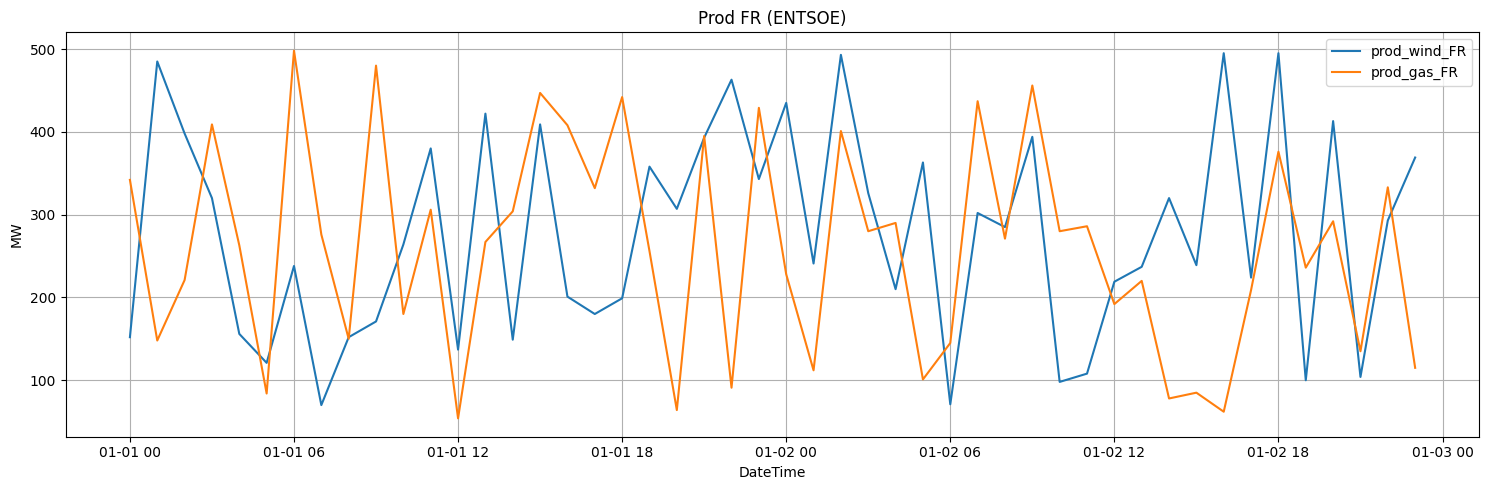

In [3]:
plot_timeseries(df, variables=['prod_wind_FR', 'prod_gas_FR'], title='Prod FR', ylabel='MW')


In [4]:
df_fr = construct_dataframe(df, countries=['FR'], production_name=['wind', 'gas', 'solar', 'coal', 'nuclear'])
df_fr.head()

,link_FR_DE,link_FR_IT,link_FR_ES,link_DE_FR,link_IT_FR,link_ES_FR,Demand_FR,Price_FR
DateTime,,,,,,,,
2023-01-01 00:00:00,-18,36,15,41,40,26,1132,171.425157
2023-01-01 01:00:00,-3,-18,-19,30,-17,30,1351,102.299898
2023-01-01 02:00:00,25,16,36,18,40,-11,1289,64.426483
2023-01-01 03:00:00,8,-33,12,44,-34,-6,1563,191.078490
2023-01-01 04:00:00,35,-26,35,-46,-8,45,1237,109.635803


In [5]:
# Vérifie si 'DateTime' est dans l'index
if df.index.name == 'DateTime':
    df = df.reset_index()

# Si 'DateTime' n’est ni dans les colonnes ni dans l’index : erreur
if 'DateTime' not in df.columns:
    raise ValueError("Le DataFrame doit contenir une colonne 'DateTime'.")

# Ajoute la colonne country si besoin
df['country'] = 'FR'

# Appel de la fonction
spot_price_df = compute_market_price_by_country(df, cost_dict)
spot_price_df.head()


,FR
2023-01-01 00:00:00,210
2023-01-01 01:00:00,210
2023-01-01 02:00:00,210
2023-01-01 03:00:00,210
2023-01-01 04:00:00,210


<Axes: title={'center': 'Prix estimé électricité FR'}>

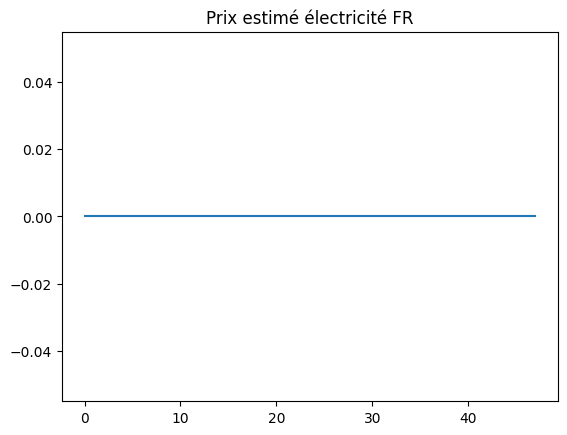

In [6]:
prod_cols = [col for col in df.columns if col.startswith('prod_') and col.endswith('_FR')]
unit_price_series = estimate_electricity_price(df, prod_cols, cost_dict, 'Demand_FR')

unit_price_series.plot(title='Prix estimé électricité FR')